# SPIN — Template: bring SPIN to your own equation

This notebook is a **practical, copy-paste template** for using SPIN on a
*custom* system, the same way the Burgers and Fisher-KPP examples are built. By
the end you will have a static / baseline / SPIN ROM for your own PDE, reusing
the entire problem-agnostic core.

You need to provide only **two pieces**:

1. a **full-order solver** with a `.step(u, tol, max_iter, verbose) -> u_new`
   method (used for the occasional out-of-span correction query), and
2. a **ROM mixin** implementing two hyper-reduced hooks:
   - `residual_sample(self, a, a_old)` — the LSPG residual at the sample points;
   - `jacobian_sample(self, a)` — the sampled LSPG test operator.

Everything else — the Newton solve, the time stepping, and the in-span /
out-of-span adaptation loop — is inherited unchanged from the core.

We use the **1D heat equation** $\partial_t u = \kappa\,\partial_{xx} u$ as a
minimal worked example, because it is the simplest possible case and keeps the
focus on *wiring*, not on the physics. Swap in your own operator and you are done.


## 1 · Setup

In [1]:
import sys, os
sys.path.insert(0, os.path.join("..", "src"))

import numpy as np
import matplotlib.pyplot as plt

# the problem-agnostic core you will build on top of:
from spin.core import compute_pod_basis, qdeim
from spin.core.rom_base import LSPGROMBase       # generic static ROM
from spin.core.adaptive_rom import SpinROMBase   # generic static/baseline/SPIN loop
from spin.diagnostics import relative_l2_error
from spin.utils import use_paper_style, PALETTE
use_paper_style()

## 2 · Step 1 — your full-order solver

The ROM needs a FOM only for the **out-of-span correction query**: once every
`zs` steps it calls `fom_solver.step(u, ...)` to take a single full-order step
from the current ROM state. Any implicit solver you already have works — it just
needs that one method (and a `.dx` attribute is convenient).

Below is a tiny backward-Euler solver for the periodic 1D heat equation. Replace
its `_residual` / `_jacobian` with your own equation; the `step` / `simulate`
scaffolding stays the same. (Compare with
`src/spin/problems/burgers/fom.py` for a nonlinear example.)

In [2]:
import scipy.sparse as sp
import scipy.sparse.linalg as spla

class HeatSolver:
    """Periodic 1D heat equation  u_t = kappa u_xx  (backward Euler)."""

    def __init__(self, Nx=256, L=1.0, kappa=1e-3, dt=1e-3):
        self.Nx, self.L, self.kappa, self.dt = Nx, L, kappa, dt
        self.dx = L / Nx
        self.x = np.linspace(0, L, Nx, endpoint=False)
        # constant backward-Euler operator  (I - dt*kappa*Lap)
        lap = (sp.diags([1, -2, 1], [-1, 0, 1], shape=(Nx, Nx), format="lil"))
        lap[0, -1] = lap[-1, 0] = 1.0                 # periodic wrap
        self._A = (sp.eye(Nx) - dt * kappa / self.dx**2 * lap).tocsr()

    def initial_condition(self):
        # a couple of bumps so several POD modes are active
        return (np.exp(-0.5*((self.x-0.35)/0.05)**2)
                + 0.6*np.exp(-0.5*((self.x-0.7)/0.07)**2))

    def step(self, u_old, tol=1e-8, max_iter=10, verbose=False):
        # linear here, so one solve; nonlinear FOMs would Newton-iterate
        return spla.spsolve(self._A, u_old)

    def simulate(self, u0, n_steps, tol=1e-8, max_iter=10, verbose=False):
        u = u0.copy(); snaps = [u.copy()]
        for _ in range(n_steps):
            u = self.step(u); snaps.append(u.copy())
        return np.stack(snaps, axis=1)   # (Nx, n_steps+1)

## 3 · Step 2 — your hyper-reduced residual and Jacobian

This is the only equation-specific ROM code. The backward-Euler LSPG residual is

$$ R(a) = \Phi_p\,(a - a_{\rm old}) + \Delta t\, R_F(\Phi a)\big|_p, $$

evaluated **only at the sample rows** `self.p_inds`, and its derivative
$W = \partial R/\partial a$. Inside the hooks the base class hands you cached
sampling data, refreshed automatically after every adaptation event:

| attribute | meaning |
|---|---|
| `self.Phi`, `self.p_inds`, `self.dt` | basis, sample indices, time step |
| `self._Phi_p` | `Phi[p_inds]` — basis at the sample rows, `(m, r)` |
| `self._Phi_up`, `self._Phi_down` | basis at the periodic right/left neighbours |
| `self._ip`, `self._im` | the neighbour indices themselves |

For the heat equation $R_F = -\kappa\,u_{xx}$, which is **linear**, so the
Jacobian does not depend on `a`. Put the two hooks in a small **mixin** so they
can be shared by the static and the adaptive ROM (exactly as the built-in
problems do).

In [3]:
class _HeatROMMixin:
    """Hyper-reduced residual / Jacobian for the heat equation.

    Expects self to carry: Phi, p_inds, dt, kappa, dx, and the cached
    sample-neighbour bases (_Phi_p, _Phi_up, _Phi_down) set by update_sampling().
    """

    def residual_sample(self, a, a_old):
        u = self.Phi @ a
        u_p, u_up, u_dn = u[self.p_inds], u[self._ip], u[self._im]
        uxx = (u_up - 2.0 * u_p + u_dn) / self.dx**2
        Fp = -self.kappa * uxx                       # R_F at the sample points
        return self._Phi_p @ (a - a_old) + self.dt * Fp

    def jacobian_sample(self, a):
        # W = d/da [ Phi_p (a - a_old) + dt * R_F ]  (a-independent here)
        lap_Phi = (self._Phi_up - 2.0 * self._Phi_p + self._Phi_down) / self.dx**2
        JfPhi = -self.kappa * lap_Phi
        return self._Phi_p + self.dt * JfPhi

## 4 · Step 3 — assemble the static and adaptive ROMs

Combine the mixin with the two core base classes via multiple inheritance —
nothing else to implement. `HeatLSPGROM` is the static ROM; `HeatSpinROM` gives
all three modes (`"static"`, `"baseline"`, `"spin"`).

> **Tip — solver convention.** If your reference run uses a direct linear solve
> in the inner LSPG step rather than a pseudoinverse, set `_use_pinv = False` on
> the mixin (the Fisher-KPP problem does this). On the square `m = r` QDEIM
> system the two agree up to round-off.

In [4]:
class HeatLSPGROM(_HeatROMMixin, LSPGROMBase):
    """Static LSPG + QDEIM ROM for the heat equation."""
    def __init__(self, Phi, p_inds, dt, kappa, dx):
        self.kappa, self.dx = kappa, dx
        super().__init__(Phi, p_inds, dt)


class HeatSpinROM(_HeatROMMixin, SpinROMBase):
    """Adaptive ROM for the heat equation (static / baseline / SPIN modes)."""
    def __init__(self, Phi, sigma, p_inds, dt, kappa, dx, zs,
                 mode="spin", gamma_in=1.0, gamma_out=0.25, fom_solver=None):
        self.kappa, self.dx = kappa, dx
        if fom_solver is None:
            fom_solver = HeatSolver(Nx=Phi.shape[0], L=dx*Phi.shape[0],
                                    kappa=kappa, dt=dt)
        super().__init__(Phi, sigma, p_inds, dt, fom_solver, zs,
                         mode=mode, gamma_in=gamma_in, gamma_out=gamma_out)

## 5 · Run it

From here it is identical to the Burgers / Fisher-KPP notebooks: build the
offline basis, then run the three modes from the same driver. Tune the control
variables below for your own problem.

In [5]:
# --- control variables -----------------------------------------------
NX, L, KAPPA, DT = 256, 1.0, 2e-3, 1e-3
N_STEPS = 400        # prediction horizon
R, M, OFFLINE = 4, 4, 4
ZS = 10              # out-of-span correction interval
GAMMA_OUT, GAMMA_IN = 0.25, 1.0

# --- FOM + offline basis ---------------------------------------------
fom = HeatSolver(Nx=NX, L=L, kappa=KAPPA, dt=DT)
snaps = fom.simulate(fom.initial_condition(), N_STEPS)
Phi0, sigma0 = compute_pod_basis(snaps[:, :OFFLINE], R)
p_inds = qdeim(Phi0, M)
a0 = Phi0.T @ snaps[:, 0]

# --- the three ROMs from one driver ----------------------------------
def run(mode):
    rom = HeatSpinROM(Phi0.copy(), sigma0.copy(), p_inds.copy(),
                      dt=DT, kappa=KAPPA, dx=fom.dx, zs=ZS,
                      mode=mode, gamma_in=GAMMA_IN, gamma_out=GAMMA_OUT)
    return rom.simulate(a0.copy(), N_STEPS)

soln = {m: run(m) for m in ("static", "baseline", "spin")}
for m, s in soln.items():
    print(f"{m:9s} mean rel-L2 = {relative_l2_error(s, snaps).mean():.3e}")

static    mean rel-L2 = 2.766e-03
baseline  mean rel-L2 = 1.313e-04
spin      mean rel-L2 = 3.322e-05


A quick look at the error histories confirms the wiring works and the three modes behave as expected.

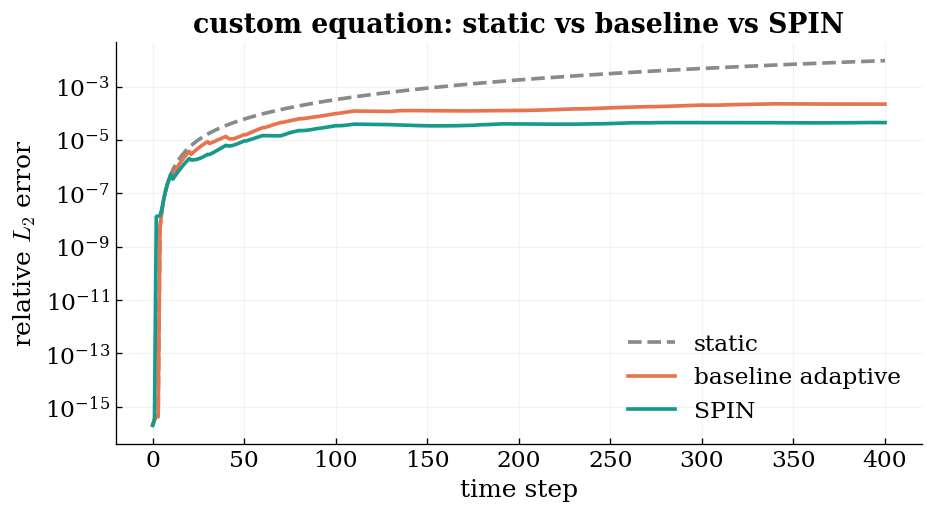

In [6]:
fig, ax = plt.subplots(figsize=(8, 4.5))
steps = np.arange(N_STEPS + 1)
for m, col in [("static", PALETTE["static"]), ("baseline", PALETTE["baseline"]),
               ("spin", PALETTE["spin"])]:
    ls = "--" if m == "static" else "-"
    ax.semilogy(steps, relative_l2_error(soln[m], snaps),
                color=col, ls=ls, lw=2.2,
                label={"static": "static", "baseline": "baseline adaptive",
                       "spin": "SPIN"}[m])
ax.set_xlabel("time step"); ax.set_ylabel(r"relative $L_2$ error")
ax.set_title("custom equation: static vs baseline vs SPIN", fontweight="bold")
ax.grid(alpha=0.15, which="both"); ax.legend(); fig.tight_layout(); plt.show()

## Checklist for your own equation

1. **FOM** — a class with `.step(u, tol, max_iter, verbose) -> u_new` and a
   `.dx` attribute. Reuse any implicit solver you have.
2. **Mixin** — implement `residual_sample(self, a, a_old)` and
   `jacobian_sample(self, a)` using the cached `self._Phi_p`, `self._Phi_up`,
   `self._Phi_down`. (Set `_use_pinv = False` if your reference uses a direct
   solve.)
3. **Two classes** — `class MyLSPGROM(MyMixin, LSPGROMBase)` and
   `class MySpinROM(MyMixin, SpinROMBase)`.
4. **Run** — build the POD basis + QDEIM indices, then call `.simulate(...)`
   in `mode="static" | "baseline" | "spin"`.

For non-periodic boundary conditions or non-nearest-neighbour stencils, adjust
how the sampled neighbours are gathered inside the hooks (you can index
`self.Phi` directly instead of using the cached neighbour bases). The reference
implementations in `src/spin/problems/` are the canonical, commented templates.